In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import pandas as pd
from scipy import stats
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

Change working directory

In [2]:
notebook_path = %pwd

os.chdir(Path(notebook_path).parent)
os.getcwd()

'/home/atleeri/repositories/forecast-electricity-markets'

Load processed data

In [3]:
processed_data_dir = Path('data/processed')
filepaths = list(processed_data_dir.glob('**/*60*.parquet'))
filepaths

[PosixPath('data/processed/opsd-time_series-2020-10-06/time_series_60min_singleindex.parquet')]

In [4]:
filepath = filepaths[0]
df = pd.read_parquet(filepath)
df

,utc_timestamp,cet_cest_timestamp,DE_wind_generation,DE_price_ahead
0,2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,NaN,NaN
1,2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,8852.0,NaN
2,2015-01-01 01:00:00+00:00,2015-01-01 02:00:00+01:00,9054.0,NaN
3,2015-01-01 02:00:00+00:00,2015-01-01 03:00:00+01:00,9070.0,NaN
4,2015-01-01 03:00:00+00:00,2015-01-01 04:00:00+01:00,9163.0,NaN
...,...,...,...,...
50396,2020-09-30 19:00:00+00:00,2020-09-30 20:00:00+01:00,10654.0,49.92
50397,2020-09-30 20:00:00+00:00,2020-09-30 21:00:00+01:00,11836.0,42.79
50398,2020-09-30 21:00:00+00:00,2020-09-30 22:00:00+01:00,12168.0,35.02
50399,2020-09-30 22:00:00+00:00,2020-09-30 23:00:00+01:00,12533.0,34.40


Subsample (for now, just use all of the data)

In [5]:
df_sample = df.sample(n=len(df), random_state=2026)

In [6]:
df_sample

,utc_timestamp,cet_cest_timestamp,DE_wind_generation,DE_price_ahead
9377,2016-01-26 16:00:00+00:00,2016-01-26 17:00:00+01:00,21511.0,NaN
8110,2015-12-04 21:00:00+00:00,2015-12-04 22:00:00+01:00,19837.0,NaN
32718,2018-09-25 05:00:00+00:00,2018-09-25 06:00:00+01:00,8811.0,NaN
25195,2017-11-15 18:00:00+00:00,2017-11-15 19:00:00+01:00,1925.0,NaN
18199,2017-01-28 06:00:00+00:00,2017-01-28 07:00:00+01:00,9643.0,NaN
...,...,...,...,...
39245,2019-06-24 04:00:00+00:00,2019-06-24 05:00:00+01:00,15501.0,35.24
29624,2018-05-19 07:00:00+00:00,2018-05-19 08:00:00+01:00,500.0,NaN
8986,2016-01-10 09:00:00+00:00,2016-01-10 10:00:00+01:00,16607.0,NaN
32134,2018-08-31 21:00:00+00:00,2018-08-31 22:00:00+01:00,4607.0,NaN


Remove NaNs

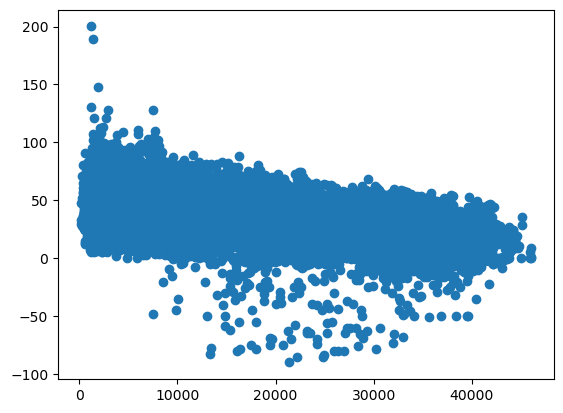

In [7]:
valid_mask = df_sample['DE_wind_generation'].notna() & df_sample['DE_price_ahead'].notna()
plt.scatter(df_sample[valid_mask]['DE_wind_generation'], df_sample[valid_mask]['DE_price_ahead'])

df_sample = df_sample[valid_mask]

### Linear Regression on All of the Data with Scipy.Stats and with PyTorch

In [8]:
X = df_sample['DE_wind_generation']
y = df_sample['DE_price_ahead']

Linear regression with scipy.stats

In [9]:
reg = stats.linregress(X, y)
reg

LinregressResult(slope=np.float64(-0.0006888959392140089), intercept=np.float64(45.709930798488095), rvalue=np.float64(-0.39179925143475863), pvalue=np.float64(0.0), stderr=np.float64(1.2215514524717343e-05), intercept_stderr=np.float64(0.21609572632577728))

Linear regression with PyTorch Linear model

In [10]:
# make tensors out of data

X_tensor = torch.tensor(df_sample['DE_wind_generation'].values, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(df_sample['DE_price_ahead'].values, dtype=torch.float32).unsqueeze(1)

In [ ]:
# create model
model = nn.Linear(1,1)

In [ ]:
# train

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.05)

nepochs = 12000

losses = []
for epoch in range(nepochs):
    optimizer.zero_grad()

    y_out = model(X_tensor)

    loss = criterion(y_out, y_tensor)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())


#### Plot Results

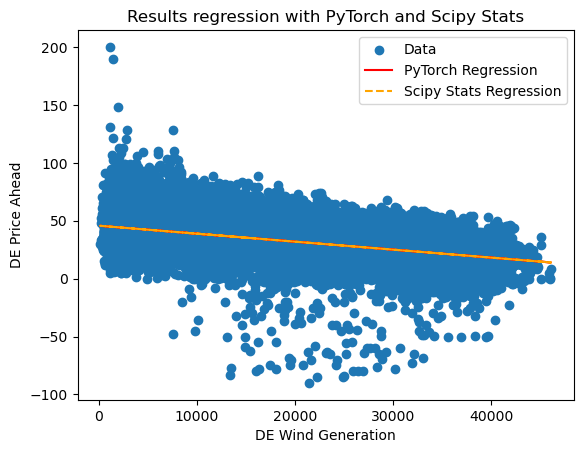

In [132]:
plt.scatter(X, y, label='Data')
with torch.no_grad():
    plt.plot(X, y_out.flatten(), 'r', label = 'PyTorch Regression')
plt.plot(X, reg[0]*X.values.flatten()+reg[1], 'orange', ls = '--', label = 'Scipy Stats Regression')
plt.title('Results regression with PyTorch and Scipy Stats')
plt.xlabel('DE Wind Generation')
plt.ylabel('DE Price Ahead')
plt.legend()

## Use Regression to Create Baseline Forecast

#### Split Dataset into Train and Test Subsets